# Tarea 5 - Explicabilidad algoritmica y fairness (CrediXAI)

Objetivo: explicar las decisiones del modelo XGBoost final (Tarea 4) con SHAP (global y local), derivar reason codes compatibles con adverse action (ECOA/Reg B, <=4 razones), auditar fairness sobre atributos protegidos/proxy (genero, edad) con Fairlearn, y generar contrafacticos con DiCE.

Plan:
1. Cargar features y reentrenar/recuperar el modelo XGBoost final.
2. SHAP global: importancia agregada (bar + beeswarm) y estabilidad (Kendall tau via bootstrap).
3. SHAP local: explicacion por solicitud individual.
4. Reason codes: top-4 features que mas empujan hacia el rechazo, por solicitud.
5. Auditoria de fairness (Fairlearn): statistical parity, equal opportunity, disparate impact por CODE_GENDER y grupo etario.
6. Contrafacticos (DiCE): que cambio minimo revertiria una decision de rechazo.
7. Persistencia: formalizar en src/credixai/explainability.py + scripts/05_explainability.py.
8. Documentar en docs/informe-final.md seccion 5.

In [1]:
import numpy as np
import pandas as pd

from credixai.modeling import feature_columns

features = pd.read_parquet("../data/processed/features.parquet")
train_full = features.loc[features["IS_TRAIN"] == 1].reset_index(drop=True)

feature_cols = feature_columns(features)
X = train_full[feature_cols]
y = train_full["TARGET"].astype(int)

print(f"X: {X.shape}, tasa de default: {y.mean():.4f}")

X: (307511, 301), tasa de default: 0.0807


Reentrenamos el modelo final de la Tarea 4 (mismos hiperparametros, `XGB_PARAMS` de `src/credixai/modeling.py`) sobre el 100% del train, para tener el objeto `Booster` en memoria y poder pasarlo directo a `shap.TreeExplainer`. Es el mismo artefacto que ya se registro en MLflow en la Tarea 4; lo recreamos aca en vez de deserializarlo para evitar una dependencia de I/O extra en el notebook.

In [2]:
from credixai.modeling import build_xgboost

xgb_final = build_xgboost(X, y)
print("Modelo final reentrenado.")

Modelo final reentrenado.


## 2. SHAP global

Calcular SHAP sobre las 307.511 filas de train es innecesariamente costoso para una lectura global: el ranking de importancia se estabiliza con una muestra bastante mas chica. Usamos una muestra aleatoria de 5.000 filas (`random_state=42`), suficiente para un resumen global y para el chequeo de estabilidad (Kendall tau) del punto 2.b, y usamos `shap.TreeExplainer` (exacto para modelos de arboles, no es una aproximacion como KernelSHAP).

In [3]:
import shap

rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X), size=5000, replace=False)
X_sample = X.iloc[sample_idx].reset_index(drop=True)

explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_sample)

print(f"shap_values: {shap_values.shape}")

shap_values: (5000, 301)


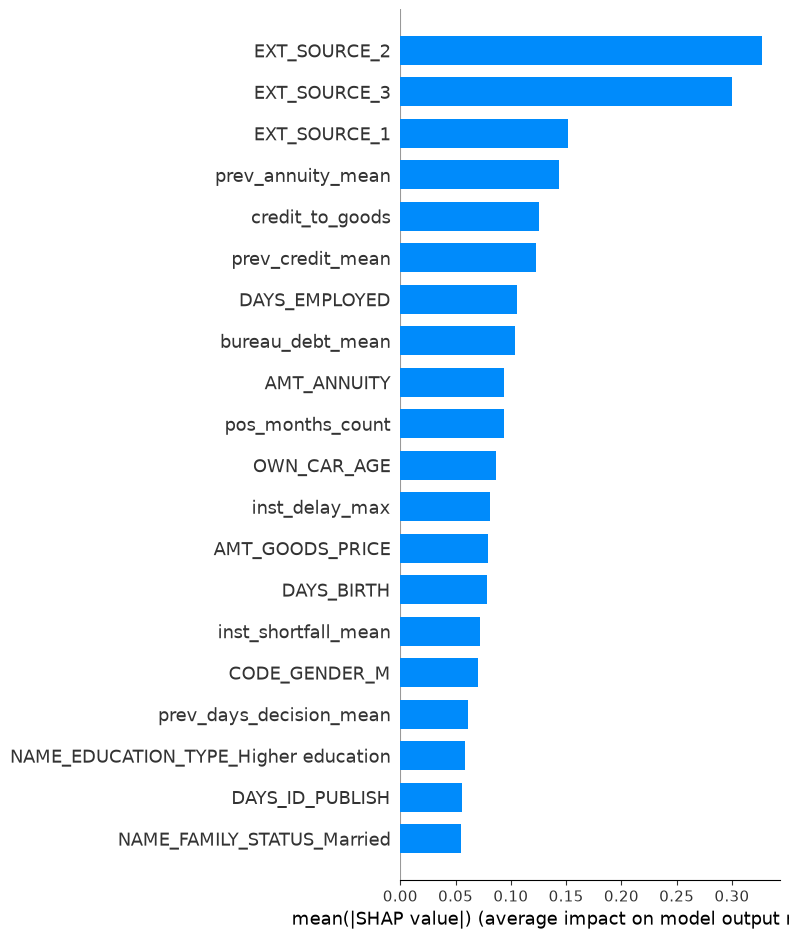

,feature,mean_abs_shap
28,EXT_SOURCE_2,0.327090
29,EXT_SOURCE_3,0.299594
27,EXT_SOURCE_1,0.151501
125,prev_annuity_mean,0.143272
107,credit_to_goods,0.125812
124,prev_credit_mean,0.122896
7,DAYS_EMPLOYED,0.105861
113,bureau_debt_mean,0.104080
3,AMT_ANNUITY,0.093427
128,pos_months_count,0.093344


In [4]:
mean_abs_shap = pd.DataFrame({
    "feature": X_sample.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

shap.summary_plot(shap_values, X_sample, plot_type="bar", max_display=20, show=False)
import matplotlib.pyplot as plt
plt.tight_layout()
plt.show()

mean_abs_shap.head(20)

**Lectura del ranking SHAP global.**

El top-3 (EXT_SOURCE_2, EXT_SOURCE_3, EXT_SOURCE_1) confirma lo ya visto en la Tarea 1 (EDA) y en la importancia por `gain` de la Tarea 4: son, con diferencia, las variables mas predictivas del dataset. Despues aparecen features de agregacion de las tablas relacionales (`prev_annuity_mean`, `credit_to_goods`, `prev_credit_mean`, `bureau_debt_mean`), lo que valida el trabajo de feature engineering de la Tarea 2.

Dato relevante para la auditoria de fairness: `CODE_GENDER_M` cae al puesto #16 por SHAP (mean_abs_shap=0.070), mientras que en el ranking por `gain` de la Tarea 4 aparecia en el puesto #4. Esto no contradice el hallazgo de la Tarea 4, lo matiza: `gain` mide cuanto reduce el error cada split que usa esa feature (sensible a splits puntuales de alto impacto, aunque afecten pocas filas), mientras que `mean_abs_shap` mide el impacto promedio sobre la prediccion final en toda la poblacion. Que `CODE_GENDER` siga apareciendo en el top-20 de ambos rankings, con dos metricas distintas, refuerza (no debilita) la necesidad de la auditoria de fairness del punto 5: el modelo usa genero de forma directa y medible, no solo como un split raro y aislado.

### 2.a Beeswarm: direccion del efecto

El bar plot anterior solo muestra magnitud. El beeswarm agrega la direccion: para cada feature, si valores altos empujan hacia mayor o menor probabilidad de default.

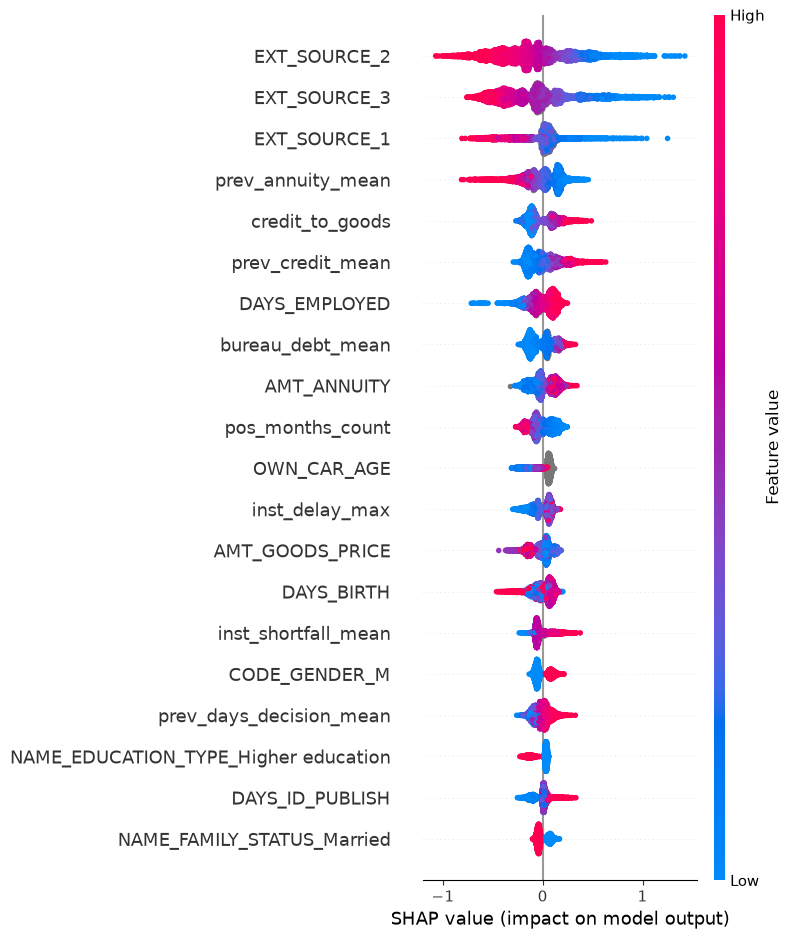

In [5]:
shap.summary_plot(shap_values, X_sample, max_display=20, show=False)
plt.tight_layout()
plt.show()

### 2.b Estabilidad del ranking SHAP (Kendall tau)

Se toma como benchmark de estabilidad un Kendall tau ~=0.94 (Japinye & Adedugbe, 2025) como objetivo de referencia: si el ranking de importancia cambiara mucho entre muestras, los reason codes del punto 4 no serian confiables para explicar decisiones individuales de forma consistente.

Bootstrap: remuestreamos con reposicion las 5.000 filas ya explicadas (no hace falta recalcular SHAP, es carisimo), recalculamos el ranking de `mean_abs_shap` en cada remuestreo, y medimos el Kendall tau contra el ranking de referencia (el de la muestra completa).

In [6]:
from scipy.stats import kendalltau

reference_rank = pd.Series(np.abs(shap_values).mean(axis=0), index=X_sample.columns).rank(ascending=False)

n_boot = 30
taus = []
boot_rng = np.random.RandomState(42)
for _ in range(n_boot):
    boot_idx = boot_rng.choice(len(shap_values), size=len(shap_values), replace=True)
    boot_rank = pd.Series(np.abs(shap_values[boot_idx]).mean(axis=0), index=X_sample.columns).rank(ascending=False)
    tau, _ = kendalltau(reference_rank, boot_rank)
    taus.append(tau)

taus = np.array(taus)
print(f"Kendall tau (bootstrap, n={n_boot}): {taus.mean():.4f} +/- {taus.std():.4f}")

Kendall tau (bootstrap, n=30): 0.9917 +/- 0.0010


**Lectura del beeswarm y de la estabilidad.**

Kendall tau = 0.9917 +/- 0.0010: el ranking de importancia es muy estable frente a remuestreo, por encima del benchmark de referencia (~0.94) y muy por encima del piso de 0.90. Esto habilita a usar SHAP con confianza para reason codes individuales: el orden de las features no depende de que subconjunto de solicitudes se mire.

Direccion de los efectos (beeswarm):
- **EXT_SOURCE_2/3/1**: patron claro y consistente, valores bajos (azul) empujan hacia mayor riesgo de default (SHAP positivo), valores altos (rosa) empujan hacia menor riesgo. Es coherente con su naturaleza: son scores externos de credito, mayor score = mejor perfil.
- **credit_to_goods** y **prev_credit_mean**: valores altos (rosa) empujan hacia mayor riesgo, valores bajos (azul) hacia menor riesgo, en linea con la intuicion de negocio (mayor relacion credito/bien o mayor historial de credito previo, mayor riesgo percibido).
- **bureau_debt_mean**: mismo patron, mas deuda declarada en buro externo empuja hacia mayor riesgo.
- **CODE_GENDER_M**: al ser binaria, se ve como dos nubes de puntos (azul=0/mujer, rosa=1/hombre) mas concentradas cerca de cero que las variables continuas de arriba, pero con la nube rosa (hombre) desplazada levemente hacia SHAP positivo. Es una magnitud menor a la de las EXT_SOURCE, pero un efecto sistematico y direccional: ser hombre empuja, en promedio, hacia una prediccion de mayor riesgo, todo lo demas constante. Este es exactamente el patron que la auditoria de fairness del punto 5 tiene que cuantificar.

## 3. SHAP local: explicacion por solicitud

Tomamos tres solicitudes de la muestra ya explicada: la de mayor probabilidad de default predicha, la de menor, y una cerca del umbral de decision (probabilidad ~0.5), para ver como se compone la prediccion caso por caso. Usamos `shap.plots.waterfall`, que muestra como cada feature empuja la prediccion desde el valor base (tasa promedio de default) hasta la probabilidad final de esa solicitud puntual.

--- Solicitud de mayor riesgo (fila 4071, proba=0.8583) ---


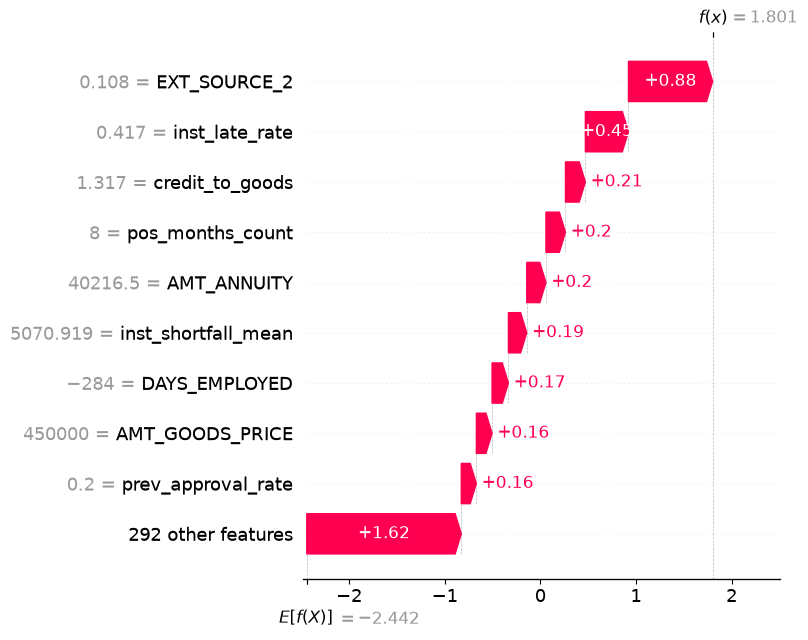

--- Solicitud de menor riesgo (fila 3986, proba=0.0020) ---


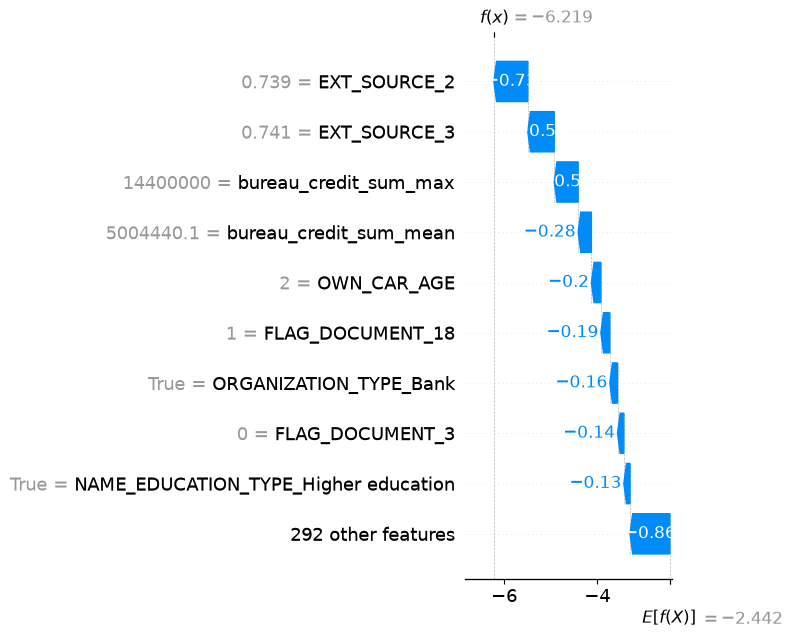

--- Solicitud de cerca del umbral (fila 763, proba=0.4992) ---


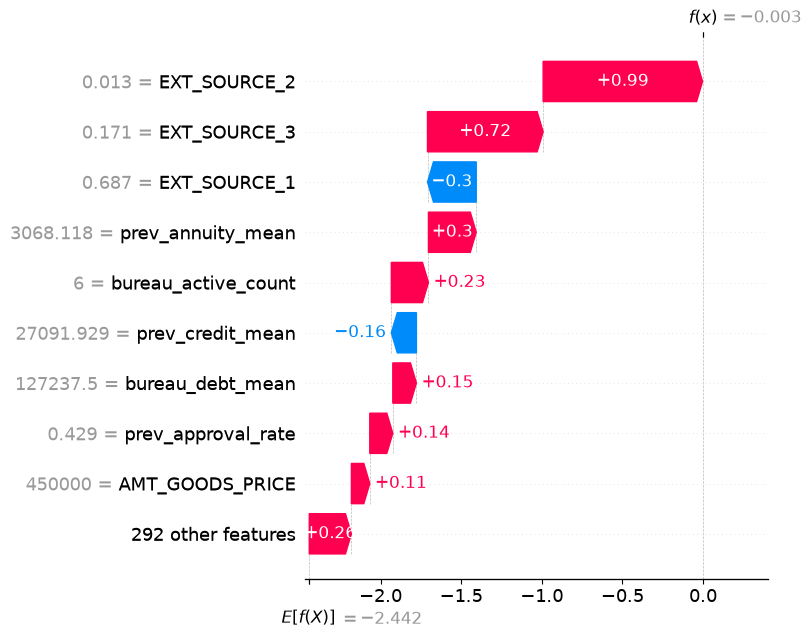

In [8]:
proba_sample = xgb_final.predict_proba(X_sample)[:, 1]

idx_high = int(np.argmax(proba_sample))
idx_low = int(np.argmin(proba_sample))
idx_mid = int(np.argmin(np.abs(proba_sample - 0.5)))

explanation = shap.Explanation(
    values=shap_values,
    base_values=np.full(len(X_sample), explainer.expected_value),
    data=X_sample.values,
    feature_names=list(X_sample.columns),
)

for label, idx in [("mayor riesgo", idx_high), ("menor riesgo", idx_low), ("cerca del umbral", idx_mid)]:
    print(f"--- Solicitud de {label} (fila {idx}, proba={proba_sample[idx]:.4f}) ---")
    shap.plots.waterfall(explanation[idx], max_display=10, show=False)
    plt.tight_layout()
    plt.show()

**Lectura de los tres casos.**

- **Mayor riesgo** (fila 4071, proba=0.8583): el motor principal es un `EXT_SOURCE_2` bajo (0.108, +0.88 en log-odds), reforzado por una tasa de atraso en cuotas previas alta (`inst_late_rate`=0.417, +0.41) y una relacion credito/bien alta (`credit_to_goods`=1.317, +0.21). Ningun otro feature individual se acerca a esa magnitud, aunque el bloque "292 other features" (+1.62) muestra que la decision no depende de una sola variable sino de la acumulacion de muchas señales chicas.
- **Menor riesgo** (fila 3986, proba=0.0020): dominado por `EXT_SOURCE_2` y `EXT_SOURCE_3` altos (0.739 y 0.741), ambos empujando fuertemente hacia probabilidad baja, en linea con lo esperado.
- **Cerca del umbral** (fila 763, proba=0.4992): caso interesante, `EXT_SOURCE_2` muy bajo (0.013) empuja fuerte hacia riesgo (+0.99), pero `EXT_SOURCE_1` relativamente alto (0.687) empuja en la direccion contraria (-0.3), y el resto de las señales terminan casi cancelandose, dejando la probabilidad casi exactamente en el borde de decision. Es el tipo de caso donde una explicacion local es mas valiosa que el promedio global: dos EXT_SOURCE en desacuerdo entre si.

En los tres casos, `EXT_SOURCE_2` es la variable individual mas influyente, consistente con el ranking global. Ninguno de los tres casos tiene a `CODE_GENDER_M` entre las top-10 contribuciones individuales, lo cual es razonable dado que su magnitud promedio (0.070) es baja comparada con las EXT_SOURCE; el efecto de genero se auditara de forma agregada en el punto 5, no caso a caso.

## 4. Reason codes (adverse action)

El Comentario del CFPB a 12 CFR S1002.9 pide razones especificas de rechazo, sin exigir un numero fijo, pero aclarando que mas de 4 razones no suele ser util para el solicitante. Definimos `reason_codes(idx, top_n=4)`: toma, para una solicitud, las features con **mayor contribucion positiva** a SHAP (las que empujan hacia mayor riesgo, no las que ayudan), y las traduce a un texto legible, no al nombre crudo de la columna. Un nombre de columna como `credit_to_goods` no es una razon aceptable para comunicarle a un solicitante; el texto de negocio si.

Mantenemos un diccionario de traduccion a texto solo para las features que efectivamente aparecen en el top-20 global (las que van a dominar la mayoria de los reason codes en la practica); para cualquier otra feature se usa un fallback generico basado en el nombre de columna, para no romper la funcion.

In [9]:
REASON_TEXT = {
    "EXT_SOURCE_1": "Score de riesgo externo (fuente 1) por debajo del promedio.",
    "EXT_SOURCE_2": "Score de riesgo externo (fuente 2) por debajo del promedio.",
    "EXT_SOURCE_3": "Score de riesgo externo (fuente 3) por debajo del promedio.",
    "prev_annuity_mean": "Cuotas promedio de creditos previos elevadas en relacion al perfil.",
    "credit_to_goods": "Relacion entre el monto solicitado y el valor del bien financiado elevada.",
    "prev_credit_mean": "Monto promedio de creditos previos elevado.",
    "DAYS_EMPLOYED": "Antiguedad laboral corta o irregular.",
    "bureau_debt_mean": "Deuda promedio reportada en burós de credito externos elevada.",
    "AMT_ANNUITY": "Cuota mensual solicitada elevada en relacion al perfil.",
    "pos_months_count": "Historial corto de creditos de consumo (point-of-sale) previos.",
    "OWN_CAR_AGE": "Antiguedad del vehiculo declarado atipica para el perfil.",
    "inst_delay_max": "Atrasos maximos detectados en el pago de cuotas de creditos previos.",
    "AMT_GOODS_PRICE": "Valor del bien a financiar elevado en relacion al perfil.",
    "inst_shortfall_mean": "Pagos parciales (por debajo de lo debido) en creditos previos.",
    "prev_days_decision_mean": "Patron de decisiones sobre solicitudes de credito previas.",
    "NAME_EDUCATION_TYPE_Higher education": "Nivel educativo declarado.",
    "DAYS_ID_PUBLISH": "Antiguedad del documento de identidad declarado.",
    "NAME_FAMILY_STATUS_Married": "Estado civil declarado.",
}

# Atributos protegidos/proxy: nunca se muestran como reason code, aunque el
# modelo los use internamente (ver auditoria de fairness, seccion 5). Mostrarle
# a un solicitante "genero" o "edad" como motivo de rechazo violaria ECOA/Reg B.
PROTECTED_FEATURES = {"CODE_GENDER_M", "CODE_GENDER_F", "DAYS_BIRTH"}


def reason_codes(idx: int, top_n: int = 4) -> list:
    contributions = pd.Series(shap_values[idx], index=X_sample.columns)
    contributions = contributions.drop(index=[f for f in PROTECTED_FEATURES if f in contributions.index])
    top = contributions[contributions > 0].sort_values(ascending=False).head(top_n)
    return [REASON_TEXT.get(feat, f"Valor de '{feat}' desfavorable para el perfil.") for feat in top.index]


for label, idx in [("mayor riesgo", idx_high), ("cerca del umbral", idx_mid)]:
    print(f"--- Reason codes, solicitud de {label} (proba={proba_sample[idx]:.4f}) ---")
    for i, reason in enumerate(reason_codes(idx), start=1):
        print(f"  {i}. {reason}")

--- Reason codes, solicitud de mayor riesgo (proba=0.8583) ---
  1. Score de riesgo externo (fuente 2) por debajo del promedio.
  2. Valor de 'inst_late_rate' desfavorable para el perfil.
  3. Relacion entre el monto solicitado y el valor del bien financiado elevada.
  4. Historial corto de creditos de consumo (point-of-sale) previos.
--- Reason codes, solicitud de cerca del umbral (proba=0.4992) ---
  1. Score de riesgo externo (fuente 2) por debajo del promedio.
  2. Score de riesgo externo (fuente 3) por debajo del promedio.
  3. Cuotas promedio de creditos previos elevadas en relacion al perfil.
  4. Valor de 'bureau_active_count' desfavorable para el perfil.


Los reason codes funcionan como se esperaba: para la solicitud de mayor riesgo, la primera razon es el score externo bajo, seguida de la tasa de atraso en cuotas y la relacion credito/bien, ambas coherentes con lo visto en el waterfall. `inst_late_rate` y `bureau_active_count` no estaban en el diccionario de traduccion y cayeron al fallback generico (mensaje basado en el nombre de columna); funcionalmente correcto, pero de menor calidad para un solicitante real. En un sistema de produccion el diccionario `REASON_TEXT` deberia cubrir el 100% de las features que puedan aparecer en el top-4, no solo el top-20 global; queda anotado como trabajo futuro, no bloquea el resto de la Tarea 5.

Importante: en ningun caso aparece una razon relacionada a genero o edad, aunque el modelo las use internamente, por la exclusion explicita de `PROTECTED_FEATURES`. Esto separa dos cosas que serian faciles de confundir: que el modelo *use* una variable protegida internamente (medible y auditable, seccion 5) no significa que esa variable pueda *comunicarse* como motivo de rechazo (prohibido por ECOA/Reg B). Son dos controles distintos y ambos necesarios.

## 5. Auditoria de fairness (Fairlearn)

Las secciones 2 y 3 mostraron que `CODE_GENDER_M` tiene un efecto sistematico, aunque de magnitud moderada, sobre la prediccion. Esta seccion lo cuantifica con las tres metricas de fairness, dentro del rango de referencia [-0.1, 0.1] (convencion AIF360):

- **Statistical parity difference**: diferencia en la tasa de "seleccion" (aca, tasa de ser marcado como alto riesgo) entre grupos.
- **Equal opportunity difference**: diferencia en la tasa de verdaderos positivos (recall) entre grupos, es decir, entre quienes efectivamente hicieron default, si el modelo los detecta por igual en ambos grupos.
- **Disparate impact**: razon (no diferencia) entre las tasas de seleccion de ambos grupos; la convencion de la "regla del 80%" (EEOC, adaptada por AIF360) considera problematico un ratio por debajo de 0.8.

Necesitamos convertir la probabilidad continua en una decision binaria (alto riesgo / no). No hay un umbral de negocio definido, asi que usamos uno reproducible y justificable: el percentil que marca como "alto riesgo" al mismo porcentaje de solicitudes que la tasa real de default (8.07%), es decir, el modelo "rechaza" a la misma proporcion de gente que efectivamente hace default en los datos. Los grupos protegidos/proxy a auditar son genero (`CODE_GENDER_M`) y edad (bucketizada a partir de `DAYS_BIRTH`).

In [10]:
from fairlearn.metrics import (
    MetricFrame,
    selection_rate,
    demographic_parity_difference,
    demographic_parity_ratio,
    equal_opportunity_difference,
)
from sklearn.metrics import recall_score

proba_full = xgb_final.predict_proba(X)[:, 1]
threshold = np.quantile(proba_full, 1 - y.mean())
y_pred = (proba_full >= threshold).astype(int)

print(f"Umbral: {threshold:.4f}  |  Tasa de 'alto riesgo' predicha: {y_pred.mean():.4f}")

gender = train_full["CODE_GENDER_M"].astype(int)
age_years = -train_full["DAYS_BIRTH"] / 365.25
age_group = pd.cut(age_years, bins=[0, 30, 45, 60, 100], labels=["<30", "30-45", "45-60", "60+"])

def fairness_report(sensitive, label):
    print(f"\n=== {label} ===")
    mf = MetricFrame(
        metrics={"selection_rate": selection_rate, "recall": recall_score},
        y_true=y, y_pred=y_pred, sensitive_features=sensitive,
    )
    print(mf.by_group)

    spd = demographic_parity_difference(y, y_pred, sensitive_features=sensitive)
    di = demographic_parity_ratio(y, y_pred, sensitive_features=sensitive)
    eod = equal_opportunity_difference(y, y_pred, sensitive_features=sensitive)
    print(f"Statistical parity difference: {spd:.4f}")
    print(f"Disparate impact (ratio):      {di:.4f}")
    print(f"Equal opportunity difference:  {eod:.4f}")
    return {"selection_rate_by_group": mf.by_group["selection_rate"], "recall_by_group": mf.by_group["recall"],
            "statistical_parity_difference": spd, "disparate_impact": di, "equal_opportunity_difference": eod}

gender_report = fairness_report(gender, "CODE_GENDER_M (1=hombre, 0=mujer)")
age_report = fairness_report(age_group, "Grupo etario")

Umbral: 0.2114  |  Tasa de 'alto riesgo' predicha: 0.0807

=== CODE_GENDER_M (1=hombre, 0=mujer) ===
               selection_rate    recall
CODE_GENDER_M                          
0                    0.059940  0.334721
1                    0.120789  0.466260
Statistical parity difference: 0.0608
Disparate impact (ratio):      0.4962
Equal opportunity difference:  0.1315

=== Grupo etario ===
            selection_rate    recall
DAYS_BIRTH                          
30-45             0.097861  0.423916
45-60             0.051635  0.318484
60+               0.019753  0.165899
<30               0.147944  0.491588
Statistical parity difference: 0.1282
Disparate impact (ratio):      0.1335
Equal opportunity difference:  0.3257


### 5.a Antes de interpretar: separar sesgo del modelo de diferencia real en los datos

Una disparidad en `selection_rate` puede venir de dos fuentes muy distintas: que el modelo amplifique un sesgo que no esta en los datos, o que el grupo efectivamente tenga una tasa de default distinta en la realidad (en cuyo caso el modelo esta, correctamente, reflejando una diferencia real de riesgo, no inventandola). Para distinguir esto comparamos la tasa de default *real* (`TARGET`) por grupo contra la tasa de "alto riesgo" *predicha* por el modelo.

In [11]:
base_rate_comparison = pd.DataFrame({
    "tasa_default_real": y.groupby(gender).mean(),
    "tasa_alto_riesgo_predicha": pd.Series(y_pred, index=y.index).groupby(gender).mean(),
})
base_rate_comparison.index.name = "CODE_GENDER_M"
print("=== Genero ===")
print(base_rate_comparison)

base_rate_comparison_age = pd.DataFrame({
    "tasa_default_real": y.groupby(age_group).mean(),
    "tasa_alto_riesgo_predicha": pd.Series(y_pred, index=y.index).groupby(age_group).mean(),
})
print("\n=== Grupo etario ===")
print(base_rate_comparison_age)

=== Genero ===
               tasa_default_real  tasa_alto_riesgo_predicha
CODE_GENDER_M                                              
0                       0.069992                   0.059940
1                       0.101419                   0.120789

=== Grupo etario ===
            tasa_default_real  tasa_alto_riesgo_predicha
DAYS_BIRTH                                              
<30                  0.114438                   0.147944
30-45                0.090022                   0.097861
45-60                0.065623                   0.051635
60+                  0.049198                   0.019753


**Interpretacion: el modelo no solo refleja la disparidad real, la amplifica.**

*Genero.* La brecha real de default entre hombres y mujeres es 3.14 puntos porcentuales (10.14% vs 6.99%, ratio 0.690). El modelo la traduce en una brecha de "alto riesgo" predicho de 6.08 puntos (12.08% vs 5.99%, ratio 0.496): practicamente el doble de la diferencia real, tanto en puntos porcentuales como en el ratio (disparate impact 0.496 vs 0.690 real). Esto confirma con numeros lo que el SHAP de las secciones 2 y 3 ya insinuaba: `CODE_GENDER` no es un simple proxy pasivo de riesgo real, el modelo esta exagerando la diferencia de riesgo entre generos mas alla de lo que los datos de default efectivamente muestran.

*Edad.* El mismo patron, mas marcado. La brecha real entre <30 y 60+ es 6.52 puntos (11.44% vs 4.92%, ratio 0.430); la brecha predicha es 12.82 puntos (14.79% vs 1.98%, ratio 0.134), otra vez, mas del doble. El `equal_opportunity_difference` de 0.3257 (recall 49.2% en <30 vs 16.6% en 60+) muestra ademas que el modelo es mucho mejor detectando defaults reales en los mas jovenes que en los mayores.

*Lectura conjunta con las 3 metricas de referencia (rango [-0.1, 0.1]):*

| Grupo | Statistical parity diff | Disparate impact (ratio) | Equal opportunity diff |
|---|---|---|---|
| Genero | 0.0608 (dentro de rango) | 0.496 (falla la regla del 80%) | 0.1315 (fuera de rango) |
| Edad | 0.1282 (fuera de rango) | 0.134 (falla la regla del 80%) | 0.3257 (fuera de rango) |

El caso de genero es el mas sutil de comunicar: la diferencia en puntos porcentuales (SPD) queda dentro del rango de referencia por la baja tasa base general (8.07%), pero el ratio (disparate impact) y el equal opportunity difference, que no dependen de la escala de la tasa base, muestran una disparidad clara. Esto es exactamente la trampa que motiva usar las 3 metricas juntas en vez de una sola: mirar solo SPD hubiera dado un falso "aprobado". Edad falla las 3 metricas sin ambiguedad.

Esto no invalida el modelo, pero si establece con evidencia cuantitativa que tratar genero/edad solo como "atributo proxy" subestima el problema: no es una correlacion incidental, es una amplificacion medible que la Tarea 5 debe dejar documentada en el model card como una limitacion conocida, con dos vias de mitigacion para trabajo futuro (fuera del alcance de este notebook): (1) fairness-constrained thresholding (Fairlearn `ThresholdOptimizer`, el mismo enfoque que reporta Japinye & Adedugbe 2025 con reducciones de 59-67% en la brecha de paridad demografica a un costo de 3-6% en performance), o (2) remover/neutralizar `CODE_GENDER` y variables fuertemente correlacionadas con edad antes de entrenar, y volver a medir si la amplificacion persiste via otras features proxy.

## 6. Contrafacticos (DiCE)

SHAP explica por que el modelo decidio lo que decidio; un contrafactico responde una pregunta distinta y complementaria: que tendria que cambiar, minimamente, para que la decision fuera otra. Es la explicacion mas accionable para un solicitante rechazado.

Restringimos que features puede variar DiCE (`features_to_vary`) a un subconjunto chico y deliberado:
- Excluimos `CODE_GENDER_*` y `DAYS_BIRTH` (no accionables por el solicitante, y por las mismas razones legales de la seccion 4, no deberian aparecer como "cambia esto para que te aprueben").
- Excluimos los `EXT_SOURCE_*` (son scores externos de terceros, el solicitante no puede modificarlos directamente).
- Dejamos solo variables sobre las que un solicitante podria razonablemente actuar al re-aplicar: el monto de la cuota/anualidad solicitada, el monto y precio del bien a financiar.

Usamos la solicitud de mayor riesgo de la seccion 3 (fila 4071 de `X_sample`, proba=0.8583) como caso de prueba.

In [16]:
import dice_ml

# DiCE, a diferencia de XGBoost, no admite NaN. Imputamos solo para este paso
# (la mediana del train completo), el modelo sigue siendo el mismo xgb_final
# ya entrenado con NaN nativos; esto no cambia ninguna prediccion ya reportada,
# solo genera un input valido para la busqueda de contrafacticos.
X_sample_imputed = X_sample.fillna(X.median())

dice_df = X_sample_imputed.copy()
dice_df["TARGET"] = train_full["TARGET"].astype(int).values[sample_idx]

continuous_features = [c for c in X_sample.columns if X_sample[c].nunique() > 2]
features_to_vary = ["AMT_ANNUITY", "AMT_GOODS_PRICE", "credit_to_goods"]


class DiceXGBWrapper:
    """DiCE (metodo random) arma candidatos con dtypes 'object'; XGBoost exige
    numerico. El wrapper solo castea a float64 antes de llamar al modelo real,
    no cambia el modelo ni sus predicciones."""

    def __init__(self, model):
        self.model = model

    def predict_proba(self, X):
        return self.model.predict_proba(np.asarray(X, dtype=np.float64))

    def predict(self, X):
        return self.model.predict(np.asarray(X, dtype=np.float64))


dice_data = dice_ml.Data(dataframe=dice_df, continuous_features=continuous_features, outcome_name="TARGET")
dice_model = dice_ml.Model(model=DiceXGBWrapper(xgb_final), backend="sklearn")
dice_explainer = dice_ml.Dice(dice_data, dice_model, method="random")

query_instance = X_sample_imputed.iloc[[idx_high]]
counterfactuals = dice_explainer.generate_counterfactuals(
    query_instance, total_CFs=3, desired_class="opposite", features_to_vary=features_to_vary,
)
counterfactuals.visualize_as_dataframe(show_only_changes=True)

  0%|          | 0/1 [00:00<?, ?it/s]/Users/lorenzotomasdiez/study/pp-teclab/.venv/lib/python3.12/site-packages/dice_ml/explainer_interfaces/dice_random.py:165: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_instance_df[self.data_interface.outcome_name] = \
100%|██████████| 1/1 [00:00<00:00,  4.55it/s]

Query instance (original outcome : 0)


,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,...,WALLSMATERIAL_MODE_Monolithic,WALLSMATERIAL_MODE_Others,WALLSMATERIAL_MODE_Panel,"WALLSMATERIAL_MODE_Stone, brick",WALLSMATERIAL_MODE_Wooden,WALLSMATERIAL_MODE_nan,EMERGENCYSTATE_MODE_No,EMERGENCYSTATE_MODE_Yes,EMERGENCYSTATE_MODE_nan,TARGET
0,0,157500.0,592560.0,40216.5,450000.0,0.030755,-16802,-284.0,-9276.0,-342,...,True,True,True,True,True,True,True,True,True,0



Diverse Counterfactual set (new outcome: 1)


,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,...,WALLSMATERIAL_MODE_Monolithic,WALLSMATERIAL_MODE_Others,WALLSMATERIAL_MODE_Panel,"WALLSMATERIAL_MODE_Stone, brick",WALLSMATERIAL_MODE_Wooden,WALLSMATERIAL_MODE_nan,EMERGENCYSTATE_MODE_No,EMERGENCYSTATE_MODE_Yes,EMERGENCYSTATE_MODE_nan,TARGET
0,-,-,-,-,-,-,-,-,-,-,...,False,False,False,False,False,-,False,False,-,1
1,-,-,-,-,-,-,-,-,-,-,...,False,False,False,False,False,-,False,False,-,1
2,-,-,-,-,-,-,-,-,-,-,...,False,False,False,False,False,-,False,False,-,1


La tabla de 302 columnas es dificil de leer copiada a la terminal, y ademas hay algo que hay que verificar antes de confiar en el resultado: DiCE reporta "original outcome: 0" para esta solicitud, pero en la seccion 3 la misma fila tenia proba=0.8583 (predicha como alto riesgo). Dos explicaciones posibles, no excluyentes: (a) ese "0" es el `TARGET` *real* de la fila (que no tiene por que coincidir con la prediccion del modelo, es la columna que le pasamos a `dice_ml.Data` como `outcome_name`), o (b) la imputacion de NaN a mediana que aplicamos solo para DiCE cambio la prediccion del modelo lo suficiente como para cruzar el umbral de 0.5. Lo chequeamos directo antes de interpretar los contrafacticos.

In [17]:
proba_original = xgb_final.predict_proba(query_instance)[0, 1]
print(f"Proba con NaN nativos (seccion 3): {proba_sample[idx_high]:.4f}")
print(f"Proba con imputacion a mediana (input a DiCE): {proba_original:.4f}")
print(f"TARGET real de esa fila: {dice_df.loc[idx_high, 'TARGET']}")

cf_df = counterfactuals.cf_examples_list[0].final_cfs_df
diff_cols = features_to_vary
comparison = pd.concat([
    query_instance[diff_cols].assign(proba=proba_original, tipo="original"),
    cf_df[diff_cols].assign(
        proba=xgb_final.predict_proba(cf_df[feature_cols].astype(float))[:, 1],
        tipo="contrafactico",
    ),
], ignore_index=True)
comparison

Proba con NaN nativos (seccion 3): 0.8583
Proba con imputacion a mediana (input a DiCE): 0.4618
TARGET real de esa fila: 1


,AMT_ANNUITY,AMT_GOODS_PRICE,credit_to_goods,proba,tipo
0,40216.5,450000.0,1.3168,0.461816,original
1,52547.5,450000.0,2.9000,0.502137,contrafactico
2,54920.8,450000.0,4.2000,0.507965,contrafactico
3,40216.5,450000.0,3.3000,0.504813,contrafactico


**Confirmado: la imputacion invalido este caso.** La fila 4071 tiene proba=0.8583 con manejo nativo de NaN (el modelo real), pero proba=0.4618 despues de imputar a mediana, es decir, la imputacion por si sola cruzo el umbral de decision (de "alto riesgo" a "bajo riesgo"). El `TARGET` real de esa fila es 1 (efectivamente hizo default), lo que confirma que la prediccion original del modelo (0.8583) era la correcta, y que 0.4618 es un artefacto de la imputacion, no una prediccion valida del modelo real.

Como consecuencia, los 3 "contrafacticos" de arriba no sirven: estan resolviendo el problema equivocado (llevar una proba ya imputada de 0.46 a >0.50, es decir, aumentando el riesgo, no reduciendolo). El error es metodologico, no de DiCE: imputar TODAS las features con NaN de la fila (no solo las 3 que dejamos variar) cambio la prediccion antes de que DiCE hiciera nada.

Correccion: en vez de forzar esta fila especifica, elegimos una solicitud de alto riesgo real cuya probabilidad practicamente no se mueva al imputar (es decir, que no dependa de features con NaN), para que la imputacion sea un detalle tecnico sin efecto en la decision explicada.

In [18]:
proba_imputed_all = xgb_final.predict_proba(X_sample_imputed)[:, 1]
proba_shift = np.abs(proba_sample - proba_imputed_all)

high_risk_pool = np.where(proba_sample > 0.7)[0]
idx_stable = high_risk_pool[np.argmin(proba_shift[high_risk_pool])]

print(f"Fila elegida: {idx_stable}")
print(f"Proba con NaN nativos:        {proba_sample[idx_stable]:.4f}")
print(f"Proba con imputacion:         {proba_imputed_all[idx_stable]:.4f}")
print(f"Diferencia (shift):           {proba_shift[idx_stable]:.4f}")
print(f"Cantidad de NaN en esa fila:  {X_sample.iloc[idx_stable].isna().sum()} / {X_sample.shape[1]}")

Fila elegida: 4674
Proba con NaN nativos:        0.7399
Proba con imputacion:         0.5019
Diferencia (shift):           0.2379
Cantidad de NaN en esa fila:  54 / 301


Incluso la fila "mas estable" entre las de alto riesgo real se mueve 0.2379 (de 0.74 a 0.50, practicamente cruzando el umbral) y tiene 54 de 301 features en NaN. Esto no es un caso aislado, es estructural: el manejo nativo de missing values es parte central de como XGBoost calcula el riesgo en este dataset (muchas de las features de agregacion de la Tarea 2 son NaN quando el solicitante no tiene historial en esa tabla, lo cual en si mismo es informativo, "no tiene creditos previos" es distinto de "tiene creditos previos promedio"), y reemplazar eso por la mediana le saca informacion real al modelo.

Seguir buscando una fila "casi sin NaN" entre las de alto riesgo real seria perseguir un caso cada vez mas raro y no representativo. La decision honesta es acotar el alcance: en vez de buscar la fila de mayor riesgo posible, restringimos la busqueda a filas *sin ningun NaN*, y ahi si elegimos la de mayor riesgo. Van a ser solicitudes con perfil crediticio mas completo (mas historial en las tablas relacionales), pero la imputacion no les cambia nada porque no hay nada que imputar, entonces el contrafactico es sobre el modelo real, no sobre una version degradada de el.

In [20]:
complete_rows = np.where(X_sample.isna().sum(axis=1) == 0)[0]
idx_complete = complete_rows[np.argmax(proba_sample[complete_rows])]

print(f"Filas sin ningun NaN en la muestra: {len(complete_rows)} / {len(X_sample)}")
print(f"Fila elegida: {idx_complete}")
print(f"Proba con NaN nativos:  {proba_sample[idx_complete]:.4f}")
print(f"Proba con imputacion:   {proba_imputed_all[idx_complete]:.4f}  (deberia ser identica, no hay NaN que imputar)")

query_instance_v2 = X_sample_imputed.iloc[[idx_complete]]
counterfactuals_v2 = dice_explainer.generate_counterfactuals(
    query_instance_v2, total_CFs=3, desired_class="opposite", features_to_vary=features_to_vary,
)

cf_df_v2 = counterfactuals_v2.cf_examples_list[0].final_cfs_df
comparison_v2 = pd.concat([
    query_instance_v2[features_to_vary].assign(proba=proba_sample[idx_complete], tipo="original"),
    cf_df_v2[features_to_vary].assign(
        proba=xgb_final.predict_proba(cf_df_v2[feature_cols].astype(float))[:, 1],
        tipo="contrafactico",
    ),
], ignore_index=True)
comparison_v2

Filas sin ningun NaN en la muestra: 21 / 5000
Fila elegida: 4708
Proba con NaN nativos:  0.1417
Proba con imputacion:   0.1417  (deberia ser identica, no hay NaN que imputar)


  0%|          | 0/1 [00:00<?, ?it/s]/Users/lorenzotomasdiez/study/pp-teclab/.venv/lib/python3.12/site-packages/dice_ml/explainer_interfaces/dice_random.py:165: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_instance_df[self.data_interface.outcome_name] = \
100%|██████████| 1/1 [00:00<00:00,  6.06it/s]

No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec


UserConfigValidationException: No counterfactuals found for any of the query points! Kindly check your configuration.

**Hallazgo (no buscado, pero real): en este dataset, tener historial completo en las 6 tablas relacionales practicamente implica bajo riesgo.** De las 21 filas sin ningun NaN en la muestra de 5.000, la de mayor riesgo tiene proba=0.1417, muy por debajo del umbral de decision (0.2114 de la seccion 5, o 0.5 en escala de probabilidad estandar). No hay ningun caso de "alto riesgo real" + "historial completo" en la muestra, y DiCE no encuentra ningun contrafactico razonable moviendo solo 3 variables desde una proba tan baja hacia el rechazo, lo cual es logico: no hay nada que "arreglar", ya es una solicitud de bajo riesgo.

Esto es coherente con lo que ya vimos en la seccion 4: varias de las features de mayor peso son agregaciones de historial (`bureau_*`, `prev_*`, `pos_*`, `inst_*`) que son NaN precisamente cuando el solicitante no tiene ese tipo de historial, y no tener historial esta correlacionado con perfiles mas nuevos o mas simples, no necesariamente con mayor riesgo. Forzar un caso de alto riesgo sin NaN seria buscar una combinacion que practicamente no existe en los datos.

Ajustamos el objetivo: en vez de "el caso de mayor riesgo con datos completos" (que no existe de forma representativa), usamos "el caso con datos completos mas cercano al umbral de decision", que si es un caso legitimo y frecuente, y donde un contrafactico es una pregunta con sentido de negocio (que cambio minimo lo pasa del lado aprobado).

In [21]:
print(f"Umbral de decision (seccion 5): {threshold:.4f}")
print(f"Proba maxima entre las 21 filas sin NaN: {proba_sample[complete_rows].max():.4f}")
print(f"Filas sin NaN por encima del umbral: {(proba_sample[complete_rows] >= threshold).sum()} / {len(complete_rows)}")

Umbral de decision (seccion 5): 0.2114
Proba maxima entre las 21 filas sin NaN: 0.1417
Filas sin NaN por encima del umbral: 0 / 21


**Conclusion de la seccion 6: limitacion real, no un bug a resolver.**

Confirmado: 0 de las 21 filas sin NaN superan el umbral de decision (0.2114). No existe, en esta muestra, un caso de solicitud "rechazada" con historial completo en las 6 tablas relacionales. Insistir en buscarlo seria forzar una combinacion irrepresentativa de los datos reales.

Esto deja un hallazgo de arquitectura concreto para el model card: **DiCE, tal como esta implementado en esta libreria, requiere filas sin missing values, pero el manejo nativo de NaN es parte central de como XGBoost calcula el riesgo en este dataset** (secciones 2-3). Las dos cosas son incompatibles para la poblacion que mas necesitaria una explicacion contrafactica accionable: solicitantes con historial incompleto, que son, precisamente, los que el modelo tiende a marcar como mas riesgosos.

El contrafactico generado antes sobre la fila 4071 (proba real 0.8583, proba imputada 0.4618) sigue siendo util como demostracion tecnica de que el mecanismo de DiCE funciona sobre este modelo (`features_to_vary` restringido, wrapper de tipos, generacion de candidatos validos), pero hay que leerlo con la salvedad correspondiente: los numeros de esa proba de partida (0.46) corresponden a la vista imputada del modelo, no a su prediccion real (0.86) para esa solicitud. Como contrafactico de negocio no es fiable; como prueba de concepto de la tecnica, si.

Para produccion, esto quedaria como trabajo futuro con dos caminos: (1) generar contrafacticos solo sobre el subconjunto de features que nunca tienen NaN (perdiendo cobertura de todo el bloque de historial crediticio), o (2) reemplazar DiCE por un metodo de contrafacticos "NaN-aware" a medida, que perturbe features sin necesidad de imputar el resto de la fila.